## Problem 4: Logistic regression in practice

**Part a**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rpy2.robjects import default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro

ro.r('install.packages("ISLR", repos="https://cloud.r-project.org")')
importr('ISLR')
ro.r('data(Auto, package="ISLR")')
auto_r = ro.r['Auto']

with localconverter(default_converter + pandas2ri.converter):
    df = ro.conversion.rpy2py(auto_r)

df['mpg01'] = (df['mpg'] > df['mpg'].median()).astype(int)
print(df.shape)
print(df[['mpg', 'mpg01']].head())

R callback write-console: Installing package into ‘/accounts/campus/oli.may1/R/x86_64-pc-linux-gnu-library-ubuntu-24.04/4.5’
(as ‘lib’ is unspecified)
  
R callback write-console: trying URL 'https://cloud.r-project.org/src/contrib/ISLR_1.4.tar.gz'
  
R callback write-console: Content type 'application/x-gzip'  
R callback write-console:  length 1756715 bytes (1.7 MB)
  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: 

(392, 10)
    mpg  mpg01
1  18.0      0
2  15.0      0
3  18.0      0
4  16.0      0
5  17.0      0


**Part b**

In [3]:
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
1  18.0        8.0         307.0       130.0  3504.0          12.0  70.0   
2  15.0        8.0         350.0       165.0  3693.0          11.5  70.0   
3  18.0        8.0         318.0       150.0  3436.0          11.0  70.0   
4  16.0        8.0         304.0       150.0  3433.0          12.0  70.0   
5  17.0        8.0         302.0       140.0  3449.0          10.5  70.0   

   origin                       name  mpg01  
1     1.0  chevrolet chevelle malibu      0  
2     1.0          buick skylark 320      0  
3     1.0         plymouth satellite      0  
4     1.0              amc rebel sst      0  
5     1.0                ford torino      0  


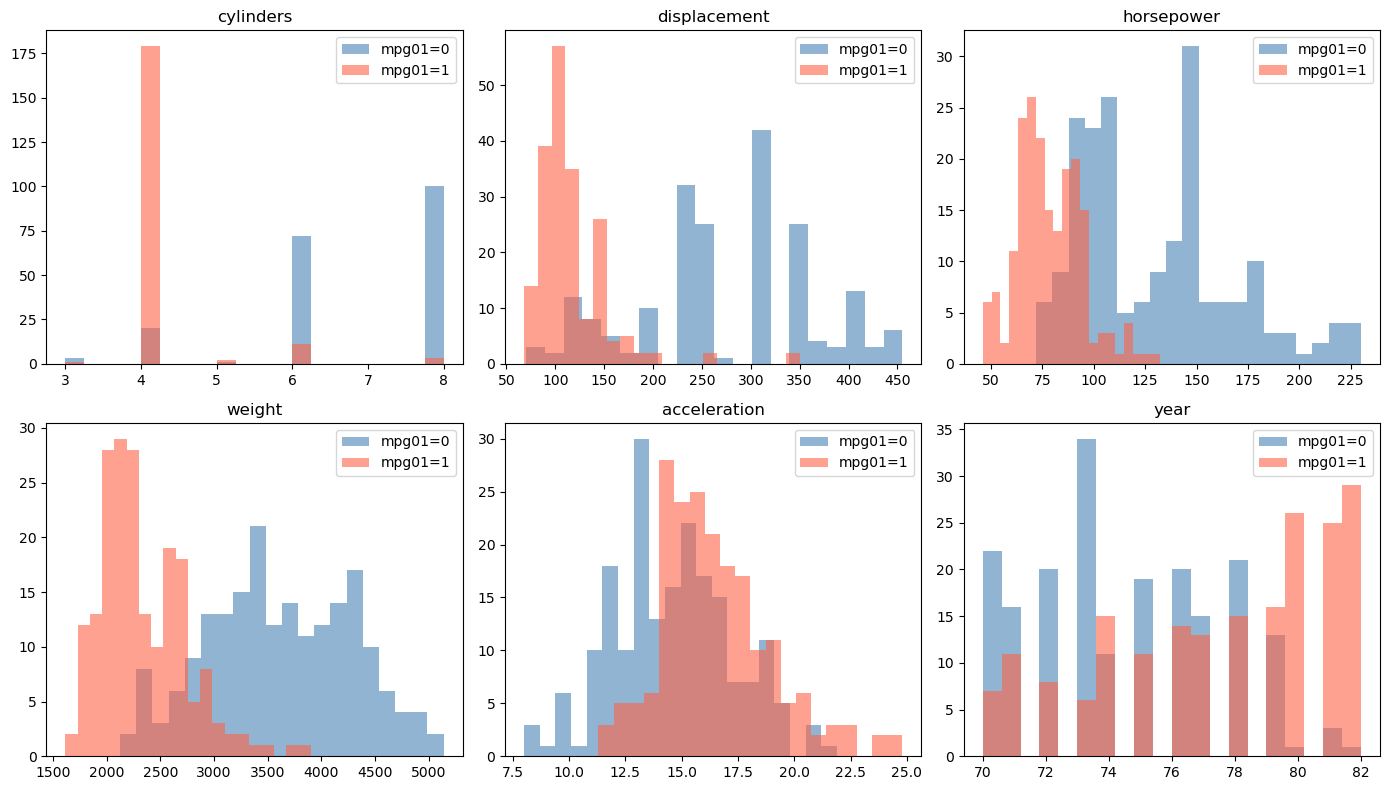

In [ ]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), features):
    for val, label, color in [(0, 'mpg01=0', 'steelblue'), (1, 'mpg01=1', 'tomato')]:
        ax.hist(df.loc[df['mpg01'] == val, feat], alpha=0.6, label=label, color=color, bins=20)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

The histograms above show the distribution of each feature broken down by `mpg01`.

The clearest class separation appears in:

**Weight**: `mpg01=1` cars peak around 2000–2500 lbs, `mpg01=0` cars around 3500–4500 lbs. This is the cleanest separation of any feature.

**Displacement**: high-mpg cars concentrate below 150 cu.in., low-mpg cars spread from 200–450.

**Cylinders**: `mpg01=1` cars are almost exclusively 4-cylinder; `mpg01=0` cars cluster at 6 and 8.

**Horsepower**: high-mpg cars concentrate below 100 hp, low-mpg cars extend to 225.

**Year**: a moderate signal — newer cars (79–82) skew toward `mpg01=1`, older cars (70–74) toward `mpg01=0`, but with more overlap than the features above.

**Acceleration**: distributions overlap heavily around 13–16 seconds; weak discriminative power.

Based on these plots, I select `cylinders`, `displacement`, `horsepower`, and `weight` predictors for part (c).

**Part c**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

selected = ['displacement', 'horsepower', 'weight', 'cylinders']

X = df[selected].values
y = df['mpg01'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

test_err = 1 - accuracy_score(y_test, clf.predict(X_test))
print(f"Test error (selected features): {test_err:.4f}")

Test error (selected features): 0.1013


The data was split 80/20 into training and test sets. Logistic regression was fit on the training set using `cylinders`, `displacement`, `horsepower`, and `weight` as predictors. The model achieves a test accuracy of 89.87%. Not bad!

**Part d**

In [7]:
# Dropping
all_features = [c for c in df.columns if c not in ['mpg', 'mpg01', 'name']]

X_full = df[all_features].values
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y, test_size=0.2, random_state=42)

clf_full = LogisticRegression(max_iter=1000)
clf_full.fit(X_train_f, y_train_f)

test_err_full = 1 - accuracy_score(y_test_f, clf_full.predict(X_test_f))
print(f"Test error (all features): {test_err_full:.4f}")
print(f"Test error (selected features): {test_err:.4f}")

Test error (all features): 0.1266
Test error (selected features): 0.1013


The selected-features model outperforms the full model, the additional predictors in the full model introduce noise rather than useful signal. The selected model is thus preferred.

**Part e**

In [10]:
import statsmodels.api as sm

X_sm = sm.add_constant(df[all_features].values)
logit_model = sm.Logit(y, X_sm).fit()
print(logit_model.summary2())

Optimization terminated successfully.
         Current function value: 0.200944
         Iterations 9
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.710     
Date:               2026-04-20 15:12 AIC:              173.5398  
No. Observations:   392              BIC:              205.3099  
Df Model:           7                Log-Likelihood:   -78.770   
Df Residuals:       384              LL-Null:          -271.71   
Converged:          1.0000           LLR p-value:      2.5305e-79
No. Iterations:     9.0000           Scale:            1.0000    
-------------------------------------------------------------------
         Coef.     Std.Err.      z      P>|z|     [0.025     0.975]
-------------------------------------------------------------------
const   -17.1549     5.7638   -2.9763   0.0029   -28.4517   -5.8580
x1       -0.1626     0.4232   -0.3842   0.7008    -0.9920 

In [11]:
# Exponentiated coefficient for year
year_coef = logit_model.params[coef_names.index('year')]
year_exp = np.exp(year_coef)
print(f"Coefficient for year: {year_coef:.4f}")
print(f"Exponentiated coefficient: {year_exp:.4f}")

Coefficient for year: 0.4295
Exponentiated coefficient: 1.5364


In the full model, only `weight` and`year`have statistically significant coefficients at the 5% level. Focusing on `year`: the exponentiated coefficient is $e^{0.4295} \approx 1.536$. This means that for each additional model year, the odds of a car having above-median fuel efficiency are multiplied by approximately 1.54, holding all other variables constant. This should reflect the steady improvement in fuel economy over the period covered by the dataset.